In [2]:
# !pip install missingno
import pandas as pd
import numpy as np
import seaborn as sns
import missingno as msno


In [3]:
df = pd.read_csv('googleplaystore.csv')

In [4]:
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


In [6]:
df.shape

(10841, 13)

Data Cleaning

1.which of the following has null values

<Axes: >

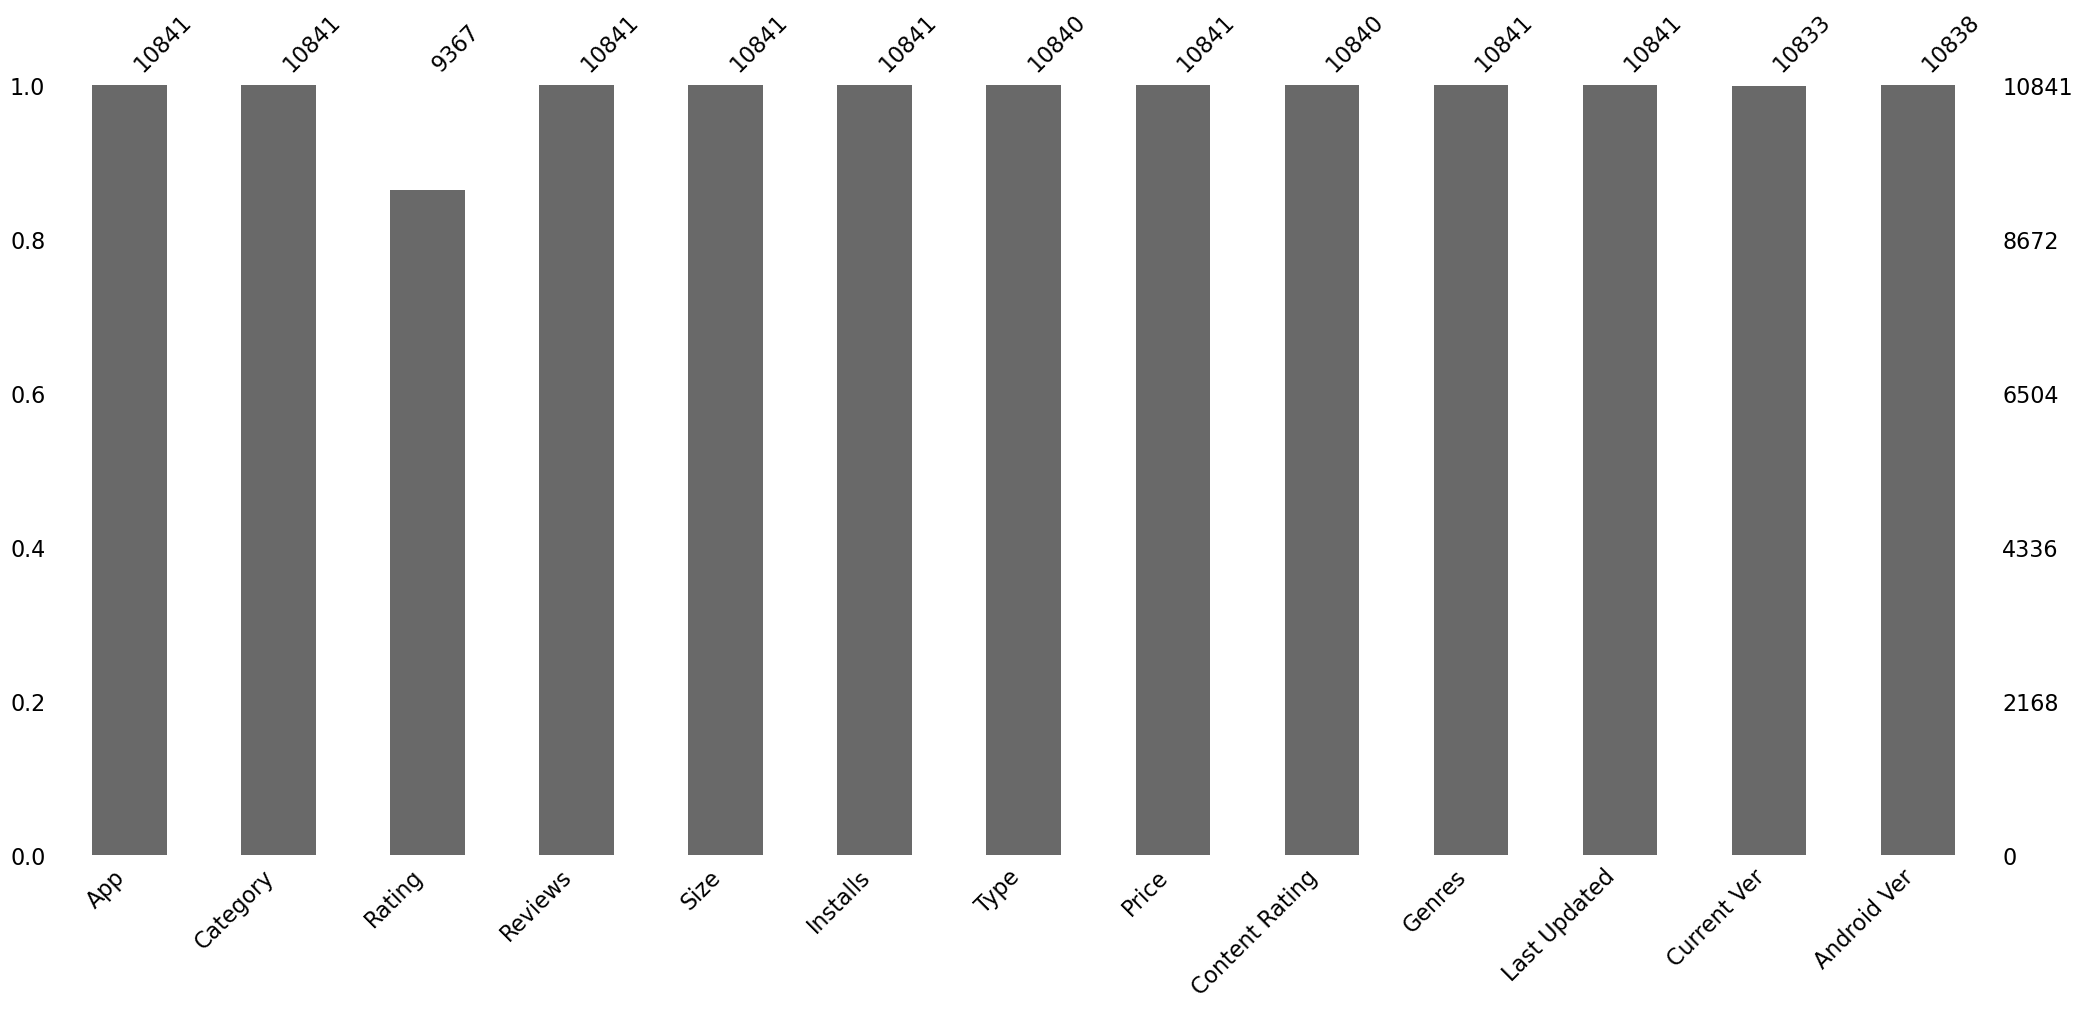

In [8]:
msno.bar(df)

In [11]:
#which of the following columns have null values
df.isna().sum().sort_values(ascending=False)

Rating            1474
Current Ver          8
Android Ver          3
Content Rating       1
Type                 1
Size                 0
Reviews              0
Category             0
App                  0
Price                0
Installs             0
Last Updated         0
Genres               0
dtype: int64

2.Clean the Rating columns and the other columns containing null values

In [14]:
df.loc[df['Rating'] > 5,'Rating'] = np.nan

In [15]:
df['Rating'].mean()

np.float64(4.191757420456972)

In [16]:
df['Rating'].fillna(df['Rating'].mean(),inplace=False)

0        4.100000
1        3.900000
2        4.700000
3        4.500000
4        4.300000
           ...   
10836    4.500000
10837    5.000000
10838    4.191757
10839    4.500000
10840    4.500000
Name: Rating, Length: 10841, dtype: float64

In [17]:
df['Rating'].mean()

np.float64(4.191757420456972)

In [18]:
df.dropna(inplace=True)

3.clean the column Reviews and make it numeric

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9360 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             9360 non-null   object 
 1   Category        9360 non-null   object 
 2   Rating          9360 non-null   float64
 3   Reviews         9360 non-null   object 
 4   Size            9360 non-null   object 
 5   Installs        9360 non-null   object 
 6   Type            9360 non-null   object 
 7   Price           9360 non-null   object 
 8   Content Rating  9360 non-null   object 
 9   Genres          9360 non-null   object 
 10  Last Updated    9360 non-null   object 
 11  Current Ver     9360 non-null   object 
 12  Android Ver     9360 non-null   object 
dtypes: float64(1), object(12)
memory usage: 1023.8+ KB


In [20]:
df['Reviews'].head()

0       159
1       967
2     87510
3    215644
4       967
Name: Reviews, dtype: object

In [25]:
df['Reviews Numeric'] = pd.to_numeric(df['Reviews'],errors='coerce')

In [27]:
df.loc[df['Reviews Numeric'].isna()].shape

(0, 14)

In [28]:
df['Reviews Numeric'].isna().sum()

np.int64(0)

How Many duplicates app are there


In [35]:
df.loc[df['Size'].str.contains('M')].head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Reviews Numeric
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up,159
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,967
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up,87510
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up,215644
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up,967


In [36]:
df.loc[df['Size'].str.contains('M'),'Size']

0         19M
1         14M
2        8.7M
3         25M
4        2.8M
         ... 
10830    2.3M
10834    2.6M
10836     53M
10837    3.6M
10840     19M
Name: Size, Length: 7466, dtype: object

In [37]:
df.loc[df['Size'].str.contains('M'),'Size'].str.replace('M','')

0         19
1         14
2        8.7
3         25
4        2.8
        ... 
10830    2.3
10834    2.6
10836     53
10837    3.6
10840     19
Name: Size, Length: 7466, dtype: object

In [42]:
pd.to_numeric(df.loc[df['Size'].str.contains('M'),'Size'].str.replace('M','')) * 1_000_000

0        19000000.0
1        14000000.0
2         8700000.0
3        25000000.0
4         2800000.0
            ...    
10830     2300000.0
10834     2600000.0
10836    53000000.0
10837     3600000.0
10840    19000000.0
Name: Size, Length: 7466, dtype: float64

In [43]:
(pd.to_numeric(df.loc[df['Size'].str.contains('M'),'Size'].str.replace('M','')) * 1_000_000).astype(str)

0        19000000.0
1        14000000.0
2         8700000.0
3        25000000.0
4         2800000.0
            ...    
10830     2300000.0
10834     2600000.0
10836    53000000.0
10837     3600000.0
10840    19000000.0
Name: Size, Length: 7466, dtype: object

In [47]:
new_size =(pd.to_numeric(df.loc[df['Size'].str.contains('M'),'Size'].str.replace('M','')) * 1_000_000).astype(str)
new_size

0        19000000.0
1        14000000.0
2         8700000.0
3        25000000.0
4         2800000.0
            ...    
10830     2300000.0
10834     2600000.0
10836    53000000.0
10837     3600000.0
10840    19000000.0
Name: Size, Length: 7466, dtype: object

4.How many duplicates apps are there

In [52]:
df.loc[df.duplicated(subset=['App'])].sort_values(by = 'App').head(10)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Reviews Numeric
1407,10 Best Foods for You,HEALTH_AND_FITNESS,4.0,2490,3.8M,"500,000+",Free,0,Everyone 10+,Health & Fitness,"February 17, 2017",1.9,2.3.3 and up,2490
2543,1800 Contacts - Lens Store,MEDICAL,4.7,23160,26M,"1,000,000+",Free,0,Everyone,Medical,"July 27, 2018",7.4.1,5.0 and up,23160
2385,2017 EMRA Antibiotic Guide,MEDICAL,4.4,12,3.8M,"1,000+",Paid,$16.99,Everyone,Medical,"January 27, 2017",1.0.5,4.0.3 and up,12
1434,21-Day Meditation Experience,HEALTH_AND_FITNESS,4.4,11506,15M,"100,000+",Free,0,Everyone,Health & Fitness,"August 2, 2018",3.0.0,4.1 and up,11506
5415,365Scores - Live Scores,SPORTS,4.6,666246,25M,"10,000,000+",Free,0,Everyone,Sports,"July 29, 2018",5.5.9,4.1 and up,666246
7035,420 BZ Budeze Delivery,MEDICAL,5.0,2,11M,100+,Free,0,Mature 17+,Medical,"June 6, 2018",1.0.1,4.1 and up,2
1970,8 Ball Pool,GAME,4.5,14201604,52M,"100,000,000+",Free,0,Everyone,Sports,"July 31, 2018",4.0.0,4.0.3 and up,14201604
1871,8 Ball Pool,GAME,4.5,14201891,52M,"100,000,000+",Free,0,Everyone,Sports,"July 31, 2018",4.0.0,4.0.3 and up,14201891
1844,8 Ball Pool,GAME,4.5,14200550,52M,"100,000,000+",Free,0,Everyone,Sports,"July 31, 2018",4.0.0,4.0.3 and up,14200550
1755,8 Ball Pool,GAME,4.5,14200344,52M,"100,000,000+",Free,0,Everyone,Sports,"July 31, 2018",4.0.0,4.0.3 and up,14200344


In [54]:
df.duplicated(keep = False).sum()

np.int64(876)

In [55]:
df.duplicated(subset=['App'],keep=False).sum()

np.int64(1959)

In [57]:
df.loc[df.duplicated(subset=['App'],keep=False) & df.duplicated(keep = False)].sort_values(by = 'App').head(10)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Reviews Numeric
1407,10 Best Foods for You,HEALTH_AND_FITNESS,4.0,2490,3.8M,"500,000+",Free,0,Everyone 10+,Health & Fitness,"February 17, 2017",1.9,2.3.3 and up,2490
1393,10 Best Foods for You,HEALTH_AND_FITNESS,4.0,2490,3.8M,"500,000+",Free,0,Everyone 10+,Health & Fitness,"February 17, 2017",1.9,2.3.3 and up,2490
2543,1800 Contacts - Lens Store,MEDICAL,4.7,23160,26M,"1,000,000+",Free,0,Everyone,Medical,"July 27, 2018",7.4.1,5.0 and up,23160
2322,1800 Contacts - Lens Store,MEDICAL,4.7,23160,26M,"1,000,000+",Free,0,Everyone,Medical,"July 27, 2018",7.4.1,5.0 and up,23160
2256,2017 EMRA Antibiotic Guide,MEDICAL,4.4,12,3.8M,"1,000+",Paid,$16.99,Everyone,Medical,"January 27, 2017",1.0.5,4.0.3 and up,12
2385,2017 EMRA Antibiotic Guide,MEDICAL,4.4,12,3.8M,"1,000+",Paid,$16.99,Everyone,Medical,"January 27, 2017",1.0.5,4.0.3 and up,12
1337,21-Day Meditation Experience,HEALTH_AND_FITNESS,4.4,11506,15M,"100,000+",Free,0,Everyone,Health & Fitness,"August 2, 2018",3.0.0,4.1 and up,11506
1434,21-Day Meditation Experience,HEALTH_AND_FITNESS,4.4,11506,15M,"100,000+",Free,0,Everyone,Health & Fitness,"August 2, 2018",3.0.0,4.1 and up,11506
2522,420 BZ Budeze Delivery,MEDICAL,5.0,2,11M,100+,Free,0,Mature 17+,Medical,"June 6, 2018",1.0.1,4.1 and up,2
7035,420 BZ Budeze Delivery,MEDICAL,5.0,2,11M,100+,Free,0,Mature 17+,Medical,"June 6, 2018",1.0.1,4.1 and up,2


5.Drop duplicated apps keeping the ones with the greatest number of reviews

In [59]:
df.loc[df.duplicated(subset=['App'],keep=False) & df.duplicated(keep=False)
       ].sort_values(by=['App','Reviews']).head(10)


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Reviews Numeric
1393,10 Best Foods for You,HEALTH_AND_FITNESS,4.0,2490,3.8M,"500,000+",Free,0,Everyone 10+,Health & Fitness,"February 17, 2017",1.9,2.3.3 and up,2490
1407,10 Best Foods for You,HEALTH_AND_FITNESS,4.0,2490,3.8M,"500,000+",Free,0,Everyone 10+,Health & Fitness,"February 17, 2017",1.9,2.3.3 and up,2490
2322,1800 Contacts - Lens Store,MEDICAL,4.7,23160,26M,"1,000,000+",Free,0,Everyone,Medical,"July 27, 2018",7.4.1,5.0 and up,23160
2543,1800 Contacts - Lens Store,MEDICAL,4.7,23160,26M,"1,000,000+",Free,0,Everyone,Medical,"July 27, 2018",7.4.1,5.0 and up,23160
2256,2017 EMRA Antibiotic Guide,MEDICAL,4.4,12,3.8M,"1,000+",Paid,$16.99,Everyone,Medical,"January 27, 2017",1.0.5,4.0.3 and up,12
2385,2017 EMRA Antibiotic Guide,MEDICAL,4.4,12,3.8M,"1,000+",Paid,$16.99,Everyone,Medical,"January 27, 2017",1.0.5,4.0.3 and up,12
1337,21-Day Meditation Experience,HEALTH_AND_FITNESS,4.4,11506,15M,"100,000+",Free,0,Everyone,Health & Fitness,"August 2, 2018",3.0.0,4.1 and up,11506
1434,21-Day Meditation Experience,HEALTH_AND_FITNESS,4.4,11506,15M,"100,000+",Free,0,Everyone,Health & Fitness,"August 2, 2018",3.0.0,4.1 and up,11506
2522,420 BZ Budeze Delivery,MEDICAL,5.0,2,11M,100+,Free,0,Mature 17+,Medical,"June 6, 2018",1.0.1,4.1 and up,2
7035,420 BZ Budeze Delivery,MEDICAL,5.0,2,11M,100+,Free,0,Mature 17+,Medical,"June 6, 2018",1.0.1,4.1 and up,2


In [60]:
df.sort_values(by=['App','Reviews'],inplace=True)

In [61]:
df.drop_duplicates(subset=['App'],keep='last',inplace=True)

6.formate the category column

In [63]:
df['Category'].value_counts()

Category
FAMILY                 1654
GAME                    895
TOOLS                   718
FINANCE                 302
PRODUCTIVITY            301
LIFESTYLE               301
PERSONALIZATION         296
MEDICAL                 290
BUSINESS                263
PHOTOGRAPHY             263
SPORTS                  260
COMMUNICATION           256
HEALTH_AND_FITNESS      244
NEWS_AND_MAGAZINES      204
SOCIAL                  203
TRAVEL_AND_LOCAL        187
SHOPPING                180
BOOKS_AND_REFERENCE     169
VIDEO_PLAYERS           149
DATING                  134
MAPS_AND_NAVIGATION     118
EDUCATION               105
FOOD_AND_DRINK           94
ENTERTAINMENT            86
AUTO_AND_VEHICLES        73
WEATHER                  72
LIBRARIES_AND_DEMO       63
HOUSE_AND_HOME           61
ART_AND_DESIGN           58
COMICS                   54
PARENTING                50
EVENTS                   45
BEAUTY                   42
Name: count, dtype: int64

In [64]:
df['Category'] = df['Category'].str.replace('_','')

In [65]:
df['Category'] = df['Category'].str.capitalize()

In [66]:
df['Category'].value_counts()

Category
Family               1654
Game                  895
Tools                 718
Finance               302
Productivity          301
Lifestyle             301
Personalization       296
Medical               290
Business              263
Photography           263
Sports                260
Communication         256
Healthandfitness      244
Newsandmagazines      204
Social                203
Travelandlocal        187
Shopping              180
Booksandreference     169
Videoplayers          149
Dating                134
Mapsandnavigation     118
Education             105
Foodanddrink           94
Entertainment          86
Autoandvehicles        73
Weather                72
Librariesanddemo       63
Houseandhome           61
Artanddesign           58
Comics                 54
Parenting              50
Events                 45
Beauty                 42
Name: count, dtype: int64

7.clean and converts the installs columns to numeric type

In [69]:
pd.to_numeric(df['Installs'],errors='coerce').isna()

8532    True
324     True
4541    True
4636    True
5940    True
        ... 
6420    True
4362    True
2575    True
7559    True
882     True
Name: Installs, Length: 8190, dtype: bool

In [72]:
df.loc[pd.to_numeric(df['Installs'],errors='coerce').isna()].head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Reviews Numeric
8532,+Download 4 Instagram Twitter,Social,4.5,40467,22M,"1,000,000+",Free,0,Everyone,Social,"August 2, 2018",5.03,4.1 and up,40467
324,- Free Comics - Comic Apps,Comics,3.5,115,9.1M,"10,000+",Free,0,Mature 17+,Comics,"July 13, 2018",5.0.12,5.0 and up,115
4541,.R,Tools,4.5,259,203k,"10,000+",Free,0,Everyone,Tools,"September 16, 2014",1.1.06,1.5 and up,259
4636,/u/app,Communication,4.7,573,53M,"10,000+",Free,0,Mature 17+,Communication,"July 3, 2018",4.2.4,4.1 and up,573
5940,058.ba,Newsandmagazines,4.4,27,14M,100+,Free,0,Everyone,News & Magazines,"July 6, 2018",1.0,4.2 and up,27


In [73]:
pd.to_numeric(df['Installs'].str.replace('+','').str.replace(',',''))

8532    1000000
324       10000
4541      10000
4636      10000
5940        100
         ...   
6420      10000
4362      10000
2575    1000000
7559      10000
882     1000000
Name: Installs, Length: 8190, dtype: int64

8.Clean and convert the size column to numeric(representing)

In [74]:
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Reviews Numeric
8532,+Download 4 Instagram Twitter,Social,4.5,40467,22M,"1,000,000+",Free,0,Everyone,Social,"August 2, 2018",5.03,4.1 and up,40467
324,- Free Comics - Comic Apps,Comics,3.5,115,9.1M,"10,000+",Free,0,Mature 17+,Comics,"July 13, 2018",5.0.12,5.0 and up,115
4541,.R,Tools,4.5,259,203k,"10,000+",Free,0,Everyone,Tools,"September 16, 2014",1.1.06,1.5 and up,259
4636,/u/app,Communication,4.7,573,53M,"10,000+",Free,0,Mature 17+,Communication,"July 3, 2018",4.2.4,4.1 and up,573
5940,058.ba,Newsandmagazines,4.4,27,14M,100+,Free,0,Everyone,News & Magazines,"July 6, 2018",1.0,4.2 and up,27


In [81]:
df.loc[df['Size'] == "Varies with device","Size"] = pd.Series('o')

In [82]:
df['Size'] = df['Size'].str.replace("Varies with device","O")

In [84]:
pd.to_numeric(df['Size'].str.replace('M','').str.replace('k',''))

8532     22.0
324       9.1
4541    203.0
4636     53.0
5940     14.0
        ...  
6420     34.0
4362     26.0
2575     18.0
7559      3.2
882       4.0
Name: Size, Length: 8190, dtype: float64

In [90]:
df.loc[df['Size'].str.contains('k',na = False)].head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Reviews Numeric
4541,.R,Tools,4.5,259,203k,"10,000+",Free,0,Everyone,Tools,"September 16, 2014",1.1.06,1.5 and up,259
4897,30-Day Ab Challenge Tracker,Healthandfitness,3.5,224,371k,"10,000+",Free,0,Everyone,Health & Fitness,"July 9, 2014",1.2.6,4.1 and up,224
4871,A-B repeater,Videoplayers,4.4,32,239k,"5,000+",Free,0,Everyone,Video Players & Editors,"May 18, 2018",1.8,3.0 and up,32
5035,AE Checkout Plugin,Shopping,3.8,208,78k,"10,000+",Free,0,Everyone,Shopping,"February 11, 2015",1.3.1,2.3 and up,208
5012,AE Order,Tools,4.1,19,317k,"1,000+",Free,0,Everyone,Tools,"November 12, 2013",2.0.131112,2.3 and up,19


In [92]:
df.loc[df['Size'].str.contains('k',na = False),'Size'].head()

4541    203k
4897    371k
4871    239k
5035     78k
5012    317k
Name: Size, dtype: object

In [93]:
df.loc[df['Size'].str.contains('k',na=False),'Size'].str.replace('k','')

4541    203
4897    371
4871    239
5035     78
5012    317
       ... 
6947    554
8205    228
5060    266
6584    704
5482    655
Name: Size, Length: 255, dtype: object

In [96]:
pd.to_numeric(df.loc[df['Size'].str.contains('k',na=False),'Size'].str.replace('k',''))*1024

4541    207872.0
4897    379904.0
4871    244736.0
5035     79872.0
5012    324608.0
          ...   
6947    567296.0
8205    233472.0
5060    272384.0
6584    720896.0
5482    670720.0
Name: Size, Length: 255, dtype: float64

In [100]:
df.loc[df['Size'].str.contains('M',na=False),'Size'] = (
    pd.to_numeric(
        df.loc[df['Size'].str.contains('M',na=False),'Size'].str.replace('M','')
    )*(1024 *1024)
).astype(str)

In [101]:
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Reviews Numeric
8532,+Download 4 Instagram Twitter,Social,4.5,40467,23068672.0,"1,000,000+",Free,0,Everyone,Social,"August 2, 2018",5.03,4.1 and up,40467
324,- Free Comics - Comic Apps,Comics,3.5,115,9542041.6,"10,000+",Free,0,Mature 17+,Comics,"July 13, 2018",5.0.12,5.0 and up,115
4541,.R,Tools,4.5,259,203k,"10,000+",Free,0,Everyone,Tools,"September 16, 2014",1.1.06,1.5 and up,259
4636,/u/app,Communication,4.7,573,55574528.0,"10,000+",Free,0,Mature 17+,Communication,"July 3, 2018",4.2.4,4.1 and up,573
5940,058.ba,Newsandmagazines,4.4,27,14680064.0,100+,Free,0,Everyone,News & Magazines,"July 6, 2018",1.0,4.2 and up,27


10.Clean and convert Price column to numeric

In [107]:
df.loc[df['Price'] != "0"]


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Reviews Numeric
7738,10 WPM Amateur ham radio CW Morse code trainer,Communication,3.5,10,3984588.8,100+,Paid,$1.49,Everyone,Communication,"May 12, 2018",2.1.4,2.1 and up,10
8219,"10,000 Quotes DB (Premium)",Booksandreference,4.1,70,3670016.0,500+,Paid,$0.99,Everyone,Books & Reference,"August 30, 2013",1.3,2.1 and up,70
6760,17th Edition Cable Sizer,Booksandreference,4.4,47,1468006.4,"1,000+",Paid,$3.08,Everyone,Books & Reference,"May 27, 2016",1.22,2.2 and up,47
7993,2 Amateur ham radio CW Morse code practice key...,Communication,4.8,6,3670016.0,100+,Paid,$1.49,Everyone,Communication,"March 5, 2018",1.0.9,1.6 and up,6
2385,2017 EMRA Antibiotic Guide,Medical,4.4,12,3984588.8,"1,000+",Paid,$16.99,Everyone,Medical,"January 27, 2017",1.0.5,4.0.3 and up,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10785,"sugar, sugar",Family,4.2,1405,9961472.0,"10,000+",Paid,$1.20,Everyone,Puzzle,"June 5, 2018",2.7,2.3 and up,1405
4951,tTorrent - ad free,Videoplayers,4.3,2976,NaN,"10,000+",Paid,$1.99,Everyone,Video Players & Editors,"June 15, 2018",1.5.14,4.1 and up,2976
4743,weather HD,Personalization,4.0,1546,4718592.0,"10,000+",Paid,$1.99,Everyone,Personalization,"February 26, 2014",3.1,2.1 and up,1546
9828,Égalité et Réconciliation,Newsandmagazines,4.9,58,3984588.8,500+,Paid,$2.99,Everyone,News & Magazines,"May 26, 2018",1.1.1,5.0 and up,58


In [114]:
pd.to_numeric(df['Price'],errors='coerce')


8532    0.0
324     0.0
4541    0.0
4636    0.0
5940    0.0
       ... 
6420    0.0
4362    NaN
2575    0.0
7559    0.0
882     0.0
Name: Price, Length: 8190, dtype: float64

In [117]:
pd.to_numeric(df['Price'].str.replace('$',''))

8532      0.00
324       0.00
4541      0.00
4636      0.00
5940      0.00
         ...  
6420      0.00
4362    399.99
2575      0.00
7559      0.00
882       0.00
Name: Price, Length: 8190, dtype: float64

10. Lets us create another column that is distribution column the column should contains Free/Paid values depending on the app's price